# Policy iteration and value iteration

In this notebook, you will implement different dynamic programming approaches described in [Sutton and Barto's book, Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html). A grid ```World``` class and policy iteration has been implemented. Feel free to add more actions, rewards and/or terminals, or to modify the code to suit your needs.

### Install dependencies

In [4]:
import sys
!{sys.executable} -m pip install pandas

### Imports

In [5]:
import numpy as np
import pandas as pd # We only use pandas for displaying tables nicely
pd.options.display.float_format = '{:,.3f}'.format

### ```World``` class and globals

The ```World``` is a grid represented as a two-dimensional array of characters where each character can represent free space, an obstacle, or a terminal. Each non-obstacle cell is associated with a reward that an agent gets for moving to that cell (can be 0). The size of the world is _width_ $\times$ _height_ characters.

A _state_ is a tuple $(x,y)$.

An empty world is created in the ```__init__``` method. Obstacles, rewards and terminals can then be added with ```add_obstacle``` and ```add_reward```.

To calculate the next state of an agent (that is, an agent is in some state $s = (x,y)$ and performs and action, $a$), ```get_next_state()```should be called. It will only be relevant to call this function later on, when we do learning based on interaction with the environment and where an agent actually has to move.

For now, you will only need the probabilities over next states given an action, $a$, that is, call ```get_state_transition_probabilities```.

In [6]:
# Globals:
ACTIONS = ("up", "down", "left", "right")

# Rewards, terminals and obstacles are characters:
REWARDS = {" ": 0, ".": 0.1, "+": 10, "-": -10}
TERMINALS = ("+", "-") # Note a terminal should also have a reward assigned
OBSTACLES = ("#")

# Discount factor
gamma = 1

# The probability of a random move:
rand_move_probability = 0

class World:
  def __init__(self, width, height):
    self.width = width
    self.height = height
    # Create an empty world where the agent can move to all cells
    self.grid = np.full((width, height), ' ', dtype='U1')

  def add_obstacle(self, start_x, start_y, end_x=None, end_y=None):
    """
    Create an obstacle in either a single cell or rectangle.
    """
    if end_x == None: end_x = start_x
    if end_y == None: end_y = start_y

    self.grid[start_x:end_x + 1, start_y:end_y + 1] = OBSTACLES[0]

  def add_reward(self, x, y, reward):
    assert reward in REWARDS, f"{reward} not in {REWARDS}"
    self.grid[x, y] = reward

  def add_terminal(self, x, y, terminal):
    assert terminal in TERMINALS, f"{terminal} not in {TERMINALS}"
    self.grid[x, y] = terminal

  def is_obstacle(self, x, y):
    if x < 0 or x >= self.width or y < 0 or y >= self.height:
      return True
    else:
      return self.grid[x ,y] in OBSTACLES

  def is_terminal(self, x, y):
    return self.grid[x ,y] in TERMINALS

  def get_reward(self, x, y):
    """
    Return the reward associated with a given location
    """
    return REWARDS[self.grid[x, y]]

  def get_next_state(self, current_state, action, deterministic=False):
    """
    Get the next state given a current state and an action. Can eiter be
    deterministic (no random actions) or non-deterministic,
    where rand_move_probability determines the probability of ignoring the
    action and performing a random move.
    """
    assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"

    x, y = current_state

    # If our current state is a terminal, there is no next state
    if self.grid[x, y] in TERMINALS:
      return None

    # Check of a random action should be performed:
    if not deterministic and np.random.rand() < rand_move_probability:
      action = np.random.choice(ACTIONS)

    if action == "up":      y -= 1
    elif action == "down":  y += 1
    elif action == "left":  x -= 1
    elif action == "right": x += 1

    # If the next state is an obstacle, stay in the current state
    return (x, y) if not self.is_obstacle(x, y) else current_state

  def get_state_transition_probabilities(self, current_state, action):
    """
    Returns a dict where key = state and value = probability given current state
    is (x,y) and "action" is performed.
    """
    assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"

    x, y = current_state
    if self.is_terminal(x, y):
      return {}

    next_state_probabilities = {}
    # Since there is rand_move_probability of performing any action, we have to
    # go through all actions and check what their next state would be:
    for a in ACTIONS:
      next_state = self.get_next_state((x, y), a, deterministic=True)
      if a == action:
        prob = 1 - rand_move_probability + rand_move_probability / len(ACTIONS)
      else:
        prob = rand_move_probability / len(ACTIONS)

      if next_state in next_state_probabilities:
        next_state_probabilities[next_state] += prob
      else:
        if prob > 0.0:
          next_state_probabilities[next_state] = prob

    return next_state_probabilities

## Basic examples: World, obstacles, rewards and terminals

Below are some examples to illustrate how the ```World``` class works.

First, we create a 4x4 world:

In [7]:
world = World(4, 4)

# Note, that we have to transpose the 2D array (.T) for (x,y)
# to match the convention when displayed
print(world.grid.T)

[[' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]


Obstacles and terminals are all represented as single characters:

In [8]:
print(f"Obstacles: {OBSTACLES}")
print(f"Terminals: {TERMINALS}")

Obstacles: #
Terminals: ('+', '-')


Rewards are also represented as characters in the world, but they have an associated value (note that defining a value for an empty space "  " is equivalent to the agent receiving that reward each time a move is made):

In [9]:
print(f"Rewards: {REWARDS}")

Rewards: {' ': 0, '.': 0.1, '+': 10, '-': -10}


To assign rewards to terminal states, just use the same character in the ```REWARDS``` dict and in the ```TERMINALS``` tuple.

In [10]:
for t in TERMINALS:
  print(f"Terminal {t} has reward {REWARDS[t]}")

world.add_terminal(0, 0, "+")
world.add_terminal(3, 3, "-")


print(world.grid.T)

# An alternative way of displaying the world using pandas:
display(pd.DataFrame(world.grid.T))

Terminal + has reward 10
Terminal - has reward -10
[['+' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' '-']]


,0,1,2,3
0,+,,,
1,,,,
2,,,,
3,,,,-


## Policies ($\pi$)

Recall that a policy, $\pi(a|s) = \Pr(A_t = a | S_t = s)$, maps states to action probabilities. In the code below, we let policies return the probabilities of each possible action given a state. States are $(x, y)$ coordinates and the policy must return action probabilities as a dict where the action is the ```key``` and the corresponding ```value``` is the probability of taking that action in the given state. Deterministic policies, for instance, return a dict with only one entry (e.g. ```{ "up": 1 } ``` if the action for the current state is ```up```).

A random policy can be defined as follows:


In [11]:
def equiprobable_random_policy(x, y):
  return { k : 1 / len(ACTIONS) for k in ACTIONS }

# Example (since the action probabilities do not depend on the state in this
# basic policy, we can just call it for state (0, 0)):
print(equiprobable_random_policy(0, 0))

{'up': 0.25, 'down': 0.25, 'left': 0.25, 'right': 0.25}


## Iterative policy evaluation


Iterative policy evaluation takes a ```World```, a discount factor, $\gamma$ (```gamma```, defined above in the ```World``` code cell), a policy, $\pi$, and a threshold, $\theta$ (```theta```), that determines when to stop the iteration. You can also specify a maximum number of iterations which can be useful for debugging using the ```max_iterations``` argument.

**IMPORTANT:** Remember that in iterative policy evaluation, we just learn state values ($V_\pi$) given a policy $\pi$. We are **not** trying to learn a policy.

(see page 74-75 of [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html) for an explanation and the algorithm)


In [12]:
def iterative_policy_evaluation(world, policy, theta=1e-5, max_iterations=1e3):

  # Our initial estimates for all states in the world is 0:
  V = np.full((world.width, world.height), 0.0)

  while True:
    # delta keeps track of the largest change in one iteration, so we set it to
    # 0 at the start of each iteration:
    delta = 0

    # Loop over all states (x,y)
    for y in range(world.height):
      for x in range(world.width):
        if not world.is_obstacle(x, y):
          # Get action probabilities for the current state:
          actions = policy(x, y)

          # v is the new estimate that will be updated in the loop:
          v = 0

          # loop over all actions that our policy says that we can perform
          # in the current state:
          for action, action_prob in actions.items():
            # For each action, get state transition probabilities and
            # accumulate in v rewards weighted with action and state transition
            # probabilities:
            for (xi, yi), state_prob in world.get_state_transition_probabilities((x, y), action).items():
              v += action_prob * state_prob * (world.get_reward(xi, yi) + gamma * V[xi, yi])

          # update delta (largest change in estimate so far)
          delta = max(delta, abs(v - V[x, y]))
          V[x, y] = v

    # check if current state value estimates are close enought to end:
    if delta <= theta:
      break

    max_iterations -= 1
    if max_iterations == 0:
      break

  # Return the state value estimates
  return V


## Implementation of Example 4.1 from the book

Below, you can see the implementation of Example 4.1 on page 76 in the book [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)

In [13]:
# World is 4x4
world = World(4, 4)

# Rewards are -1 for each move (including when hitting a terminal state, "+"):
REWARDS = {" ": -1, "+": -1}


# Add terminal states in two corners
world.add_terminal(0, 0, "+")
world.add_terminal(3, 3, "+")

print(world.grid.T)

[['+' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' '+']]


In [14]:
gamma = 1
V = iterative_policy_evaluation(world, equiprobable_random_policy)

display(pd.DataFrame(V.T))

,0,1,2,3
0,0.000,-14.000,-20.000,-22.000
1,-14.000,-18.000,-20.000,-20.000
2,-20.000,-20.000,-18.000,-14.000
3,-22.000,-20.000,-14.000,0.000


## Exercise - policy and discount factor

Experiment with example 4.1: what effect does it have to change the policy, e.g. so that an agent always goes left or always goes right? What effect does it have on state values to change the value of the discount factor (```gamma```)?

In [15]:
# TODO: implement your code here
def only_go_left_policy(x, y):
    return {
        k: 1 if k == "left" else 0 for k in ACTIONS
    }

def only_go_right_policy(x, y):
    return {
        k: 1 if k == "right" else 0 for k in ACTIONS
    }

# Example (since the action probabilities do not depend on the state in this
# basic policy, we can just call it for state (0, 0)):

# changing gamma
new_gamma = 0.5
og_gamma = 1

print("Only go left policy:")
print(only_go_left_policy(0, 0))

gamma = og_gamma
V_left = iterative_policy_evaluation(world, only_go_left_policy)
display(pd.DataFrame(V_left.T))

gamma = new_gamma
V_left_gamma_05 = iterative_policy_evaluation(world, only_go_left_policy)
display(pd.DataFrame(V_left_gamma_05.T))

print("Only go right policy:")
print(only_go_right_policy(0, 0))

gamma = og_gamma
V_right = iterative_policy_evaluation(world, only_go_right_policy)
display(pd.DataFrame(V_right.T))

gamma = new_gamma
V_right_gamma_05 = iterative_policy_evaluation(world, only_go_right_policy)
display(pd.DataFrame(V_right_gamma_05.T))

Only go left policy:
{'up': 0, 'down': 0, 'left': 1, 'right': 0}


,0,1,2,3
0,0.000,-1.000,-2.000,-3.000
1,"-1,000.000","-1,001.000","-1,002.000","-1,003.000"
2,"-1,000.000","-1,001.000","-1,002.000","-1,003.000"
3,"-1,000.000","-1,001.000","-1,002.000",0.000


,0,1,2,3
0,0.000,-1.000,-1.500,-1.750
1,-2.000,-2.000,-2.000,-2.000
2,-2.000,-2.000,-2.000,-2.000
3,-2.000,-2.000,-2.000,0.000


Only go right policy:
{'up': 0, 'down': 0, 'left': 0, 'right': 1}


,0,1,2,3
0,0.000,"-1,000.000","-1,000.000","-1,000.000"
1,"-1,000.000","-1,000.000","-1,000.000","-1,000.000"
2,"-1,000.000","-1,000.000","-1,000.000","-1,000.000"
3,-3.000,-2.000,-1.000,0.000


,0,1,2,3
0,0.000,-2.000,-2.000,-2.000
1,-2.000,-2.000,-2.000,-2.000
2,-2.000,-2.000,-2.000,-2.000
3,-1.750,-1.500,-1.000,0.000


Try to write a policy that is deterministic, but where the action performed differs between states. You can implement it as a two-dimensional array with the dimensions corresponding to the world dimensions and have each entry be an action for the corresponding state.

In [16]:
# TODO: implement you code here

policy_grid = [
    ["left", "left", "left", "left"],
    ["up", "up", "up", "up"],
    ["up", "up", "up", "up"],
    ["up", "up", "up", "up"]
]
policy_grid_2 = [
    ["left", "right", "right", "down"],
    ["right", "up", "up", "down"],
    ["up", "down", "down", "left"],
    ["up", "left", "left", "right"]
]

def differ_between_state_policy(x, y):
    return {
        k : 1 if k == policy_grid_2[y][x] else 0 for k in ACTIONS
    }
rand_move_probability = 0
print(differ_between_state_policy(0, 0))
gamma = 1
V_differ_between_state = iterative_policy_evaluation(world, differ_between_state_policy)

display(pd.DataFrame(V_differ_between_state.T))

{'up': 0, 'down': 0, 'left': 1, 'right': 0}


,0,1,2,3
0,0.000,"-1,996.000","-1,997.000","-2,001.000"
1,"-1,997.000","-1,997.000","-1,998.000","-2,002.000"
2,"-1,998.000","-2,000.000","-2,001.000","-2,002.000"
3,"-1,999.000","-2,000.000","-2,001.000",0.000


## Exercise - stochasticity

You can adjust the degree of stochasticity in the environment by setting the global variable ```rand_move_probability``` (the probability of the world ignoring an action and performing a random move instead). What effect does stochasticity have on the state-value estimates?


In [17]:
# TODO: implement you code here
rand_move_probability = 0.5

V_differ_between_state_rand_05 = iterative_policy_evaluation(world, differ_between_state_policy)

display(pd.DataFrame(V_differ_between_state_rand_05.T))

# if the policy is optimal, it will take longer to reach terminal. but if it never reaches terminal with rand = 0 then rand != 0 can find it

,0,1,2,3
0,0.000,-28.373,-32.089,-31.196
1,-26.890,-30.163,-32.273,-29.417
2,-29.417,-32.273,-30.163,-26.890
3,-31.196,-32.089,-28.373,0.000


## Exercise - robot, cake and mouse trap

Implement a robot, cake and mouse trap example and compute state value estimates under different policies (equiprobable, always right, always right:50% or up:50%) with and without stochasticity.


In [18]:
# TODO: implement you code here

REWARDS = {" ": 0, "+": 1, "-": -1}

my_world = World(4, 3)
my_world.add_terminal(3, 0, "+")
my_world.add_terminal(3, 1, "-")
my_world.add_obstacle(1, 1)

display(pd.DataFrame(my_world.grid.T))

rand_move_probability = 0
gamma = 0.9

# equiprobable
print("normal equiprobable_random_policy")
V_norm_equi = iterative_policy_evaluation(my_world, equiprobable_random_policy)
display(pd.DataFrame(V_norm_equi.T))

print("stochasticity equiprobable_random_policy")
rand_move_probability = 0.5
V_rand_equi = iterative_policy_evaluation(my_world, equiprobable_random_policy)
display(pd.DataFrame(V_rand_equi.T))

# always right
print("only_go_right_policy")
rand_move_probability = 0
V_norm_right = iterative_policy_evaluation(my_world, only_go_right_policy)
display(pd.DataFrame(V_norm_right.T))

print("stochasticity only_go_right_policy")
rand_move_probability = 0.2
V_rand_right = iterative_policy_evaluation(my_world, only_go_right_policy)
display(pd.DataFrame(V_rand_right.T))

# 50% right, 50% up
print("right_50_left_50_policy")
def right_50_left_50_policy(x, y):
    return {
        k : 0.5 if (k == "right" or k == "up") else 0 for k in ACTIONS
    }

print(right_50_left_50_policy(1,1))
rand_move_probability = 0
V_norm_50_up_right = iterative_policy_evaluation(my_world, right_50_left_50_policy, max_iterations = 0)
display(pd.DataFrame(V_norm_50_up_right.T))

print("stochasticity right_50_left_50_policy")
rand_move_probability = 0.5
V_norm_50_up_right = iterative_policy_evaluation(my_world, right_50_left_50_policy)
display(pd.DataFrame(V_norm_50_up_right.T))

,0,1,2,3
0,,,,+
1,,#,,-
2,,,,


normal equiprobable_random_policy


,0,1,2,3
0,0.049,0.127,0.262,0.000
1,-0.007,0.000,-0.337,0.000
2,-0.066,-0.155,-0.312,-0.582


stochasticity equiprobable_random_policy


,0,1,2,3
0,0.049,0.127,0.262,0.000
1,-0.007,0.000,-0.337,0.000
2,-0.066,-0.155,-0.312,-0.582


...

,0,1,2,3
0,0.658,0.777,0.886,0.000
1,0.100,0.000,-0.864,0.000
2,-0.236,-0.287,-0.327,-0.341


right_50_left_50_policy
{'up': 0.5, 'down': 0, 'left': 0, 'right': 0.5}


,0,1,2,3
0,0.609,0.744,0.909,0.000
1,0.498,0.000,-0.091,0.000
2,0.058,-0.368,-0.450,-0.909


stochasticity right_50_left_50_policy


,0,1,2,3
0,0.297,0.427,0.596,0.000
1,0.174,0.000,-0.249,0.000
2,-0.040,-0.266,-0.420,-0.768


## Exercise - action-value function

Based on a set of calculated state values, try to implement an action value function, that is $q_\pi(s, a)$ (if in doubt, see page 78 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)). Note: you have to use the ```get_state_transition_probabilities()``` method on ```World``` to be able to handle stochastic environments where performing ```a``` does not lead to a deterministic outcome.

In [19]:
# testing stuff

x, y = 2, 2 # x er mod højre, y er nedad
state = (x, y)

smth = my_world.get_state_transition_probabilities(state, "down")


def action_value(world, V, state, action):
  q = 0
  next_state_probability = world.get_state_transition_probabilities(state, action)

  for (next_x, next_y), state_prob in next_state_probability.items():
    reward = world.get_reward(next_x, next_y)
    q += state_prob * (reward + gamma * V[next_x, next_y])

  return q

rand_move_probability = 0
gamma = 0.9
display(pd.DataFrame(V_norm_right.T))

val = action_value(my_world, V_norm_right, state, "up")
val_policy = (V_norm_right[x][y])

print(f"val if go up first: {val}")
print(f"val if just follow policy: {val_policy}")

,0,1,2,3
0,0.810,0.900,1.000,0.000
1,0.000,0.000,-1.000,0.000
2,0.000,0.000,0.000,0.000


val if go up first: -0.9
val if just follow policy: 0.0


## Exercise - policy iteration

You are now ready to implement policy iteration. That is, first estimate state values under a given policy, then improve the policy based on those estimates and action values, estimate state values again, and so on. See page 80 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)

You will need an explicit representation of your policy that you can easily change.

Test your implementation and print out the policies found.


In [31]:
def visualize_best_actions(world, V):
    """Show the best action (highest q-value) for each state"""
    best_actions = np.full((world.width, world.height), ' ', dtype='U10')
    
    # Symbols for directions
    action_symbols = {
        'up': '↑',
        'down': '↓', 
        'left': '←',
        'right': '→'
    }
    
    for y in range(world.height):
        for x in range(world.width):
            if world.is_obstacle(x, y):
                best_actions[x, y] = '#'
            elif world.is_terminal(x, y):
                best_actions[x, y] = world.grid[x, y]
            else:
                # Find action with highest q-value
                best_action = max(ACTIONS, 
                                key=lambda a: action_value(world, V, (x, y), a))
                best_actions[x, y] = action_symbols[best_action]
    
    print("Best action at each state (arrows show direction):")
    display(pd.DataFrame(best_actions.T))

In [ ]:
"""
Use the action_value and V to find the best option and thereby create a 
policy_map = [
        ['right', 'right',   'right', 'down'],
        ['up',    'down',    'left',  'down'],
        ['up',    'down',    'up',    'down'],
        ['up',    'left',    'up',    'left']
    ]
With ideal actions
"""
rand_move_probability = 0

def policy_iteration(world, theta=1e-5, max_iterations=1e3):
    policy = equiprobable_random_policy # just a start
    V = np.full((world.width, world.height), 0.0)
    policy_grid = np.full((world.width, world.height), "", dtype=object) # need object type to have string

    while True:
        V = iterative_policy_evaluation(world, policy, theta=1e-5, max_iterations=1e3)
        
        # policy improvement
        policy_stable = True
        for y in range(world.height):
            for x in range(world.width):
                if not world.is_obstacle(x, y):
                    state_values = []
                    policy_dict = policy(x, y)
                    old_action = max(policy_dict, key=policy_dict.get) # get max value in dict
                    
                    for action in ACTIONS:
                        state_values.append(action_value(world, V, (x, y), action)) # get action value

                    a_best = ACTIONS[np.argmax(state_values)]
                    if a_best != old_action:
                        policy_stable = False

                    policy_grid[x,y] = a_best
        policy = lambda x, y: {k : 1 if k == policy_grid[x,y] else 0 for k in ACTIONS}

        max_iterations -= 1
        if policy_stable or (max_iterations == 0):
            break

    return V

In [59]:
REWARDS = {" ": 0, "+": 1, "-": -1}

value_it_world = World(4, 3)
value_it_world.add_terminal(3, 0, "+")
value_it_world.add_terminal(3, 1, "-")
value_it_world.add_obstacle(1, 1)

display(pd.DataFrame(value_it_world.grid.T))

rand_move_probability = 0.1
gamma = 0.9
V = policy_iteration(value_it_world)

display(pd.DataFrame(V.T))

visualize_best_actions(value_it_world, V)

,0,1,2,3
0,,,,+
1,,#,,-
2,,,,


,0,1,2,3
0,0.781,0.878,0.986,0.000
1,0.696,0.000,0.831,0.000
2,0.622,0.657,0.737,0.616


Best action at each state (arrows show direction):


,0,1,2,3
0,→,→,→,+
1,↑,#,↑,-
2,↑,→,↑,←


## Exercise - value iteration

Value iteration is much more effecient than policy iteration. Implement value iteration below. See page 83 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html).

Test your implementation and display the policies found (i.e., a grid with the perferred action in each cell).

In [ ]:
action_symbols = {
        'up': '↑',
        'down': '↓', 
        'left': '←',
        'right': '→'
    }

def value_iteration(world, theta=1e-5, max_iterations=1e3):
    V = np.full((world.width, world.height), 0.0)
    while True:
        delta = 0

        for y in range(world.height):
            for x in range(world.width):
                if not world.is_obstacle(x, y): # go in if no obstacle
                    state_values = []

                    for action in ACTIONS:
                        state_values.append(action_value(world, V, (x, y), action))

                    v_best = max(state_values)
                    delta = max(delta, abs(v_best - V[x, y]))
                    V[x, y] = v_best

        max_iterations -= 1
        if (delta <= theta) or (max_iterations == 0):
            break

    return V

In [ ]:
REWARDS = {" ": 0, "+": 1, "-": -1}

value_it_world = World(4, 3)
value_it_world.add_terminal(3, 0, "+")
value_it_world.add_terminal(3, 1, "-")
value_it_world.add_obstacle(1, 1)

display(pd.DataFrame(value_it_world.grid.T))

rand_move_probability = 0.1
gamma = 0.9
V = value_iteration(value_it_world)

display(pd.DataFrame(V.T))

visualize_best_actions(value_it_world, V)

,0,1,2,3
0,,,,+
1,,#,,-
2,,,,


,0,1,2,3
0,0.781,0.878,0.986,0.000
1,0.696,0.000,0.831,0.000
2,0.622,0.657,0.737,0.616


Best action at each state (arrows show direction):


,0,1,2,3
0,→,→,→,+
1,↑,#,↑,-
2,↑,→,↑,←


In [124]:
# big map test
REWARDS = {" ": 0, ".": 5, "+": 10, "-": -10}

value_it_world = World(10, 10)
value_it_world.add_terminal(9, 0, "+")
value_it_world.add_terminal(9, 9, "+")
value_it_world.add_terminal(9, 1, "-")
value_it_world.add_terminal(9, 8, "-")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    value_it_world.add_obstacle(x, y)
# value_it_world.add_reward(5, 5, ".")
# value_it_world.add_reward(4, 5, ".")
# value_it_world.add_reward(4, 4, ".")
# value_it_world.add_reward(5, 4, ".")


display(pd.DataFrame(value_it_world.grid.T))

rand_move_probability = 0
gamma = 0.9
V = value_iteration(value_it_world)

display(pd.DataFrame(V.T))

visualize_best_actions(value_it_world, V)

,0,1,2,3,4,5,6,7,8,9
0,,,,,,,,#,,+
1,,#,#,#,,,,,,-
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,-
9,,,#,,,,,,,+


1000.0


,0,1,2,3,4,5,6,7,8,9
0,3.487,3.874,4.305,4.783,5.314,5.905,6.561,0.000,10.000,0.000
1,3.138,0.000,0.000,0.000,5.905,6.561,7.290,8.100,9.000,0.000
2,2.824,2.542,0.000,4.783,5.314,5.905,6.561,0.000,8.100,7.290
3,2.542,2.824,0.000,4.305,4.783,5.314,5.905,0.000,7.290,6.561
4,2.824,3.138,3.487,3.874,4.305,4.783,5.314,5.905,6.561,5.905
5,2.824,3.138,3.487,3.874,4.305,4.783,5.314,5.905,6.561,5.905
6,3.138,3.487,3.874,4.305,4.783,5.314,5.905,6.561,7.290,6.561
7,3.487,3.874,4.305,4.783,5.314,5.905,6.561,0.000,8.100,7.290
8,3.138,3.487,0.000,5.314,5.905,6.561,7.290,0.000,9.000,0.000
9,2.824,3.138,0.000,5.905,6.561,7.290,8.100,9.000,10.000,0.000


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,→,→,→,→,↓,↓,↓,#,→,+
1,↑,#,#,#,→,→,→,→,↑,-
2,↑,↓,#,→,↑,↑,↑,#,↑,←
3,↑,↓,#,↑,↑,↑,↑,#,↑,↑
4,→,→,→,↑,↑,↑,↑,→,↑,↑
5,↓,↓,↓,↓,↓,↓,↓,↓,↓,↓
6,↓,↓,↓,↓,↓,↓,↓,→,↓,↓
7,→,→,→,↓,↓,↓,↓,#,↓,←
8,↑,↑,#,↓,↓,↓,↓,#,↓,-
9,↑,↑,#,→,→,→,→,→,→,+


Starting performance tests...
Testing grids: 10x10, 20x20, 30x30, ..., 100x100

Testing 10x10 grid... Policy: 0.0791s Value: 0.0033s
Testing 20x20 grid... Policy: 0.3015s Value: 0.0139s
Testing 30x30 grid... Policy: 0.6998s Value: 0.0336s
Testing 40x40 grid... Policy: 2.2348s Value: 0.1888s
Testing 50x50 grid... Policy: 4.0382s Value: 0.2072s
Testing 60x60 grid... Policy: 5.5253s Value: 0.2406s
Testing 70x70 grid... Policy: 7.0979s Value: 0.3101s
Testing 80x80 grid... Policy: 10.5419s Value: 0.4259s
Testing 90x90 grid... Policy: 10.1243s Value: 0.5198s
Testing 100x100 grid... Policy: 13.3426s Value: 0.6786s
Testing 110x110 grid... Policy: 17.1688s Value: 0.7713s
Testing 120x120 grid... Policy: 19.7208s Value: 0.9253s
Testing 130x130 grid... Policy: 25.6386s Value: 1.2726s
Testing 140x140 grid... Policy: 26.9620s Value: 1.1867s
Testing 150x150 grid... Policy: 28.0245s Value: 1.1521s

Generating comparison plot...


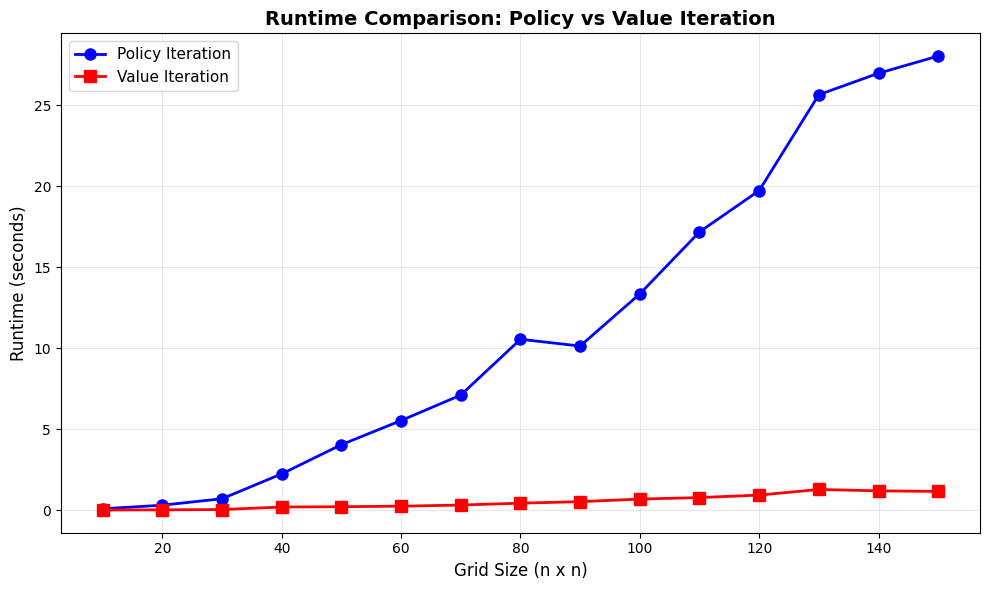

Generating difference plot...


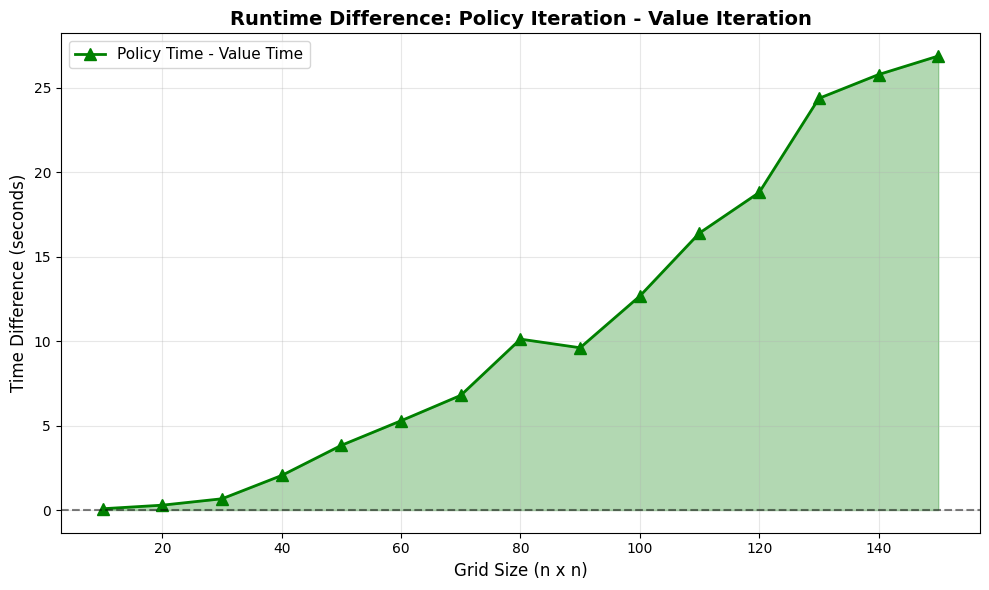


Graphs saved as 'comparison.png' and 'difference.png'


In [ ]:
import matplotlib.pyplot as plt
import time

def run_performance_tests(max_size=100, gamma_value=0.9, rand_prob=0):
    """
    Test policy_iteration vs value_iteration on grids at increments of 10
    (10x10, 20x20, 30x30, ..., up to max_size x max_size)
    """
    grid_sizes = []
    policy_iter_times = []
    value_iter_times = []
    
    # Set global values
    global gamma, rand_move_probability, REWARDS
    gamma = gamma_value
    rand_move_probability = rand_prob
    REWARDS = {" ": 0, "+": 1, "-": -1}
    
    # Test only at increments of 10
    for n in range(10, max_size + 1, 10):
        print(f"Testing {n}x{n} grid...", end=' ', flush=True)
        
        # Create world
        world = World(n, n)
        world.add_terminal(0, 0, "+")
        world.add_terminal(n-1, n-1, "-")
        
        # Test policy iteration
        start_time = time.time()
        try:
            V_policy = policy_iteration(world, max_iterations=100)
            policy_time = time.time() - start_time
            print(f"Policy: {policy_time:.4f}s", end=' ', flush=True)
        except Exception as e:
            print(f"Policy FAILED: {e}", end=' ', flush=True)
            policy_time = None
        
        # Test value iteration
        start_time = time.time()
        try:
            V_value = value_iteration(world, max_iterations=100)
            value_time = time.time() - start_time
            print(f"Value: {value_time:.4f}s")
        except Exception as e:
            print(f"Value FAILED: {e}")
            value_time = None
        
        grid_sizes.append(n)
        policy_iter_times.append(policy_time)
        value_iter_times.append(value_time)
    
    return grid_sizes, policy_iter_times, value_iter_times

def plot_comparison(grid_sizes, policy_times, value_times):
    """Plot runtime comparison"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(grid_sizes, policy_times, 'b-o', label='Policy Iteration', markersize=8, linewidth=2)
    ax.plot(grid_sizes, value_times, 'r-s', label='Value Iteration', markersize=8, linewidth=2)
    ax.set_xlabel('Grid Size (n x n)', fontsize=12)
    ax.set_ylabel('Runtime (seconds)', fontsize=12)
    ax.set_title('Runtime Comparison: Policy vs Value Iteration', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_difference(grid_sizes, policy_times, value_times):
    """Plot the difference between algorithms"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Calculate differences
    differences = [p - v if p and v else None for p, v in zip(policy_times, value_times)]
    valid_indices = [i for i, d in enumerate(differences) if d is not None]
    valid_sizes = [grid_sizes[i] for i in valid_indices]
    valid_diff = [differences[i] for i in valid_indices]
    
    ax.plot(valid_sizes, valid_diff, 'g-^', label='Policy Time - Value Time', markersize=8, linewidth=2)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.fill_between(valid_sizes, valid_diff, alpha=0.3, color='green')
    ax.set_xlabel('Grid Size (n x n)', fontsize=12)
    ax.set_ylabel('Time Difference (seconds)', fontsize=12)
    ax.set_title('Runtime Difference: Policy Iteration - Value Iteration', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('difference.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the tests
print("Starting performance tests...")
print("Testing grids: 10x10, 20x20, 30x30, ..., 100x100\n")

sizes, policy_times, value_times = run_performance_tests(max_size=150)

# Plot results
print("\nGenerating comparison plot...")
plot_comparison(sizes, policy_times, value_times)

print("Generating difference plot...")
plot_difference(sizes, policy_times, value_times)